In [ ]:
#звгрузка

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv('Bondora_raw.csv')
# Просмотр данных
print(df.shape)
print(df.head())
print(df.info())
print(df['Status'].value_counts(normalize=True))

/tmp/ipykernel_9983/3874701787.py:7: DtypeWarning: Columns (34,37,38,80,82,83,89,90) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Bondora_raw.csv')


(134529, 112)
  ReportAsOfEOD                                LoanId  LoanNumber  \
0    2020-01-27  F0660C80-83F3-4A97-8DA0-9C250112D6EC         659   
1    2020-01-27  978BB85B-1C69-4D51-8447-9C240104A3A2         654   
2    2020-01-27  EA44027E-7FA7-4BB2-846D-9C1F013C8A22         641   
3    2020-01-27  CE67AD25-2951-4BEE-96BD-9C2700C61EF4         668   
4    2020-01-27  9408BF8C-B159-4D6A-9D61-9C2400A986E3         652   

           ListedOnUTC     BiddingStartedOn  BidsPortfolioManager  BidsApi  \
0  2009-06-11 16:40:39  2009-06-11 16:40:39                     0        0   
1  2009-06-10 15:48:57  2009-06-10 15:48:57                     0        0   
2  2009-06-05 19:12:29  2009-06-05 19:12:29                     0        0   
3  2009-06-13 12:01:20  2009-06-13 12:01:20                     0        0   
4  2009-06-10 10:17:13  2009-06-10 10:17:13                     0        0   

   BidsManual  UserName  NewCreditCustomer  ...  \
0    115.0410      KARU               True  ...   


In [ ]:
#упрощаем status для рисков

In [4]:
def create_target(status):
    if status == 'Late':
        return 1  # риск дефолта
    elif status in ['Current', 'Repaid']:
        return 0  # нет риска
    else:
        return None

df['loan_default'] = df['Status'].apply(create_target)

# проверка распределения
print(df['loan_default'].value_counts(normalize=True))

loan_default
0    0.659761
1    0.340239
Name: proportion, dtype: float64


In [ ]:
#выбираем столбцы

In [5]:
selected_cols = [
    'Age', 'Gender', 'Education', 'MaritalStatus', 'NrOfDependants',
    'OccupationArea', 'HomeOwnershipType',
    'IncomeTotal', 'DebtToIncome', 'FreeCash', 'LiabilitiesTotal',
    'EmploymentStatus', 'EmploymentDurationCurrentEmployer', 'WorkExperience',
    'CreditScoreEeMini', 'CreditScoreEsEquifaxRisk', 'CreditScoreEsMicroL',
    'CreditScoreFiAsiakasTietoRiskGrade', 'NewCreditCustomer',
    'ExistingLiabilities', 'NoOfPreviousLoansBeforeLoan',
    'AmountOfPreviousLoansBeforeLoan',
    'AppliedAmount', 'Amount', 'Interest', 'LoanDuration',
    'MonthlyPayment', 'MonthlyPaymentDay', 'UseOfLoan', 'VerificationType',
    'ActiveLateCategory', 'ActiveLateLastPaymentCategory',
    'ActiveScheduleFirstPaymentReached', 'WorseLateCategory',
    'loan_default'
]

# фиксируем столбцы
df = df[selected_cols]

print(f"Осталось колонок: {df.shape[1]}")
print(f"Осталось строк: {df.shape[0]}")

Осталось колонок: 35
Осталось строк: 134529


In [ ]:
#проверка на пропуски

In [36]:
missing = df.isnull().sum()
missing_pct = missing[missing > 0] / len(df) * 100
print("Колонки с пропусками (>5%):")
print(missing_pct[missing_pct > 5])

Колонки с пропусками (>5%):
WorkExperience    72.85195
dtype: float64


In [ ]:
#заполнить нулем пропуски NrOfDependants

In [7]:
df['NrOfDependants'] = df['NrOfDependants'].fillna(0)

In [ ]:
#заполнить медианой пропуски  стажа по возрасту WorkExperience

In [40]:
# узнаем значение
print(df['WorkExperience'].unique())

['MoreThan25Years' '2To5Years' '5To10Years' '15To25Years' '10To15Years'
 'LessThan2Years' nan]


In [41]:
# замена
exp_map = {
    'LessThan2Years': 1,
    '2To5Years': 3.5,
    '5To10Years': 7.5,
    '10To15Years': 12.5,
    '15To25Years': 20,
    'MoreThan25Years': 30
}

df['WorkExperience_Num'] = df['WorkExperience'].map(exp_map)

In [ ]:
# заполнение пропусков

In [42]:
# Функция для определения возрастной группы
def age_group(age):
    if age < 25:
        return '18-24'
    elif age < 35:
        return '25-34'
    elif age < 45:
        return '35-44'
    elif age < 55:
        return '45-54'
    else:
        return '55+'

df['AgeGroup'] = df['Age'].apply(age_group)

# Заполняем пропуски медианой по возрастной группе
df['WorkExperience_Num'] = df.groupby('AgeGroup')['WorkExperience_Num'].transform(lambda x: x.fillna(x.median()))

# в случае если остались пропуски , заполняем общей медианой
df['WorkExperience_Num'] = df['WorkExperience_Num'].fillna(df['WorkExperience_Num'].median())

# удаляем колонку
df = df.drop('AgeGroup', axis=1)

In [ ]:
#Кредитные скоринги

In [16]:
# Проверим тип данных каждой колонки
for col in ['CreditScoreEeMini', 'CreditScoreEsEquifaxRisk', 'CreditScoreEsMicroL', 'CreditScoreFiAsiakasTietoRiskGrade']:
    print(f"\n=== {col} ===")
    print(f"Тип данных: {df[col].dtype}")
    print(f"Уникальные значения: {df[col].unique()[:10]}")


=== CreditScoreEeMini ===
Тип данных: float64
Уникальные значения: [1000.  700.  800.  600.  900.  500.    0.]

=== CreditScoreEsEquifaxRisk ===
Тип данных: object
Уникальные значения: [nan 'A' 'AA' 'B' 'C' 'AAA' 'D']

=== CreditScoreEsMicroL ===
Тип данных: object
Уникальные значения: [nan 'M3' 'M5' 'M1' 'M9' 'M2' 'M6' 'M4' 'M8' 'M7']

=== CreditScoreFiAsiakasTietoRiskGrade ===
Тип данных: object
Уникальные значения: [nan 'RL2' 'RL1' 'RL4' 'RL3' 'RL0' 'RL5' '2' '1' '3']


In [ ]:
#преобразование значений

In [17]:
# Словарь преобразования (чем ниже буква, тем выше риск)
equifax_map = {
    'AAA': 1,   # Лучший
    'AA': 2,
    'A': 3,
    'B': 4,
    'C': 5,
    'D': 6      # Худший
}

df['CreditScoreEsEquifaxRisk_num'] = df['CreditScoreEsEquifaxRisk'].map(equifax_map)

# Проверка результата
print(df['CreditScoreEsEquifaxRisk_num'].value_counts(dropna=False))

CreditScoreEsEquifaxRisk_num
NaN    122310
4.0      6596
5.0      3324
3.0      1746
2.0       310
6.0       195
1.0        48
Name: count, dtype: int64


In [ ]:
#тоже самое для CreditScoreEsMicroL

In [19]:
# Извлекаем число из M1, M2, ..., M10
df['CreditScoreEsMicroL_num'] = df['CreditScoreEsMicroL'].str.extract(r'(\d+)').astype(float)

# Проверь результат
print(df['CreditScoreEsMicroL_num'].value_counts(dropna=False))

CreditScoreEsMicroL_num
NaN     122013
1.0       4321
5.0       2432
2.0       1723
3.0       1644
4.0       1540
6.0        560
8.0        102
9.0         70
7.0         69
10.0        55
Name: count, dtype: int64


In [20]:
# Словарь преобразования
asiakas_map = {
    'RL0': 0,
    'RL1': 1,
    'RL2': 2,
    'RL3': 3,
    'RL4': 4,
    'RL5': 5,
    '1': 1,
    '2': 2,
    '3': 3
}

df['CreditScoreFiAsiakasTietoRiskGrade_num'] = df['CreditScoreFiAsiakasTietoRiskGrade'].map(asiakas_map)

# Проверка результата
print(df['CreditScoreFiAsiakasTietoRiskGrade_num'].value_counts(dropna=False))

CreditScoreFiAsiakasTietoRiskGrade_num
NaN    113977
3.0     10912
2.0      7127
1.0      2252
4.0       147
5.0       113
0.0         1
Name: count, dtype: int64


In [ ]:
#другие колонки

In [21]:
# работа с другими колонками
numeric_score_cols = ['CreditScoreEeMini', 'CreditScoreEsEquifaxRisk_num', 'CreditScoreEsMicroL_num', 'CreditScoreFiAsiakasTietoRiskGrade_num']

for col in numeric_score_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"{col}: заполнено пропусков медианой {median_val}")

CreditScoreEeMini: заполнено пропусков медианой 1000.0
CreditScoreEsEquifaxRisk_num: заполнено пропусков медианой 4.0
CreditScoreEsMicroL_num: заполнено пропусков медианой 3.0
CreditScoreFiAsiakasTietoRiskGrade_num: заполнено пропусков медианой 3.0


In [ ]:
#удаление колонок

In [22]:
df = df.drop(['CreditScoreEsEquifaxRisk', 'CreditScoreEsMicroL', 'CreditScoreFiAsiakasTietoRiskGrade'], axis=1)

In [ ]:
#Проверяем уникальные значения ActiveLateCategory, ActiveLateLastPaymentCategory, WorseLateCategory

In [27]:
# Проверяем уникальные значения
for col in ['ActiveLateCategory', 'ActiveLateLastPaymentCategory', 'WorseLateCategory']:
    print(f"\n=== {col} ===")
    print(f"Уникальные: {df[col].unique()[:20]}")
    print(f"Тип: {df[col].dtype}")


=== ActiveLateCategory ===
Уникальные: [nan '180+' '16-30' '1-7' '31-60' '8-15' '121-150' '91-120' '151-180'
 '61-90']
Тип: object

=== ActiveLateLastPaymentCategory ===
Уникальные: [nan '180+' '151-180' '31-60' '8-15' '1-7' '91-120' '16-30' '121-150'
 '61-90']
Тип: object

=== WorseLateCategory ===
Уникальные: ['91-120' nan '180+' '31-60' '151-180' '61-90' '1-7' '121-150' '16-30'
 '8-15']
Тип: object


In [ ]:
# обработка пропусков

In [28]:
import re

def extract_days_from_interval(category):
    """Извлекает максимальное число дней из интервала"""
    if pd.isna(category):
        return np.nan
    if category == '180+':
        return 180
    # Ищем числа в строке, например '16-30' -> 30
    numbers = re.findall(r'\d+', category)
    if len(numbers) == 2:
        return int(numbers[1])  # берем максимальное значение
    elif len(numbers) == 1:
        return int(numbers[0])
    return np.nan

# Применяем ко всем трем колонкам
for col in ['ActiveLateCategory', 'ActiveLateLastPaymentCategory', 'WorseLateCategory']:
    df[col + '_days'] = df[col].apply(extract_days_from_interval)
    # Заполняем пропуски нулем (означает отсутствие просрочки)
    df[col + '_days'] = df[col + '_days'].fillna(0)
    # Удаляем исходную строковую колонку
    df = df.drop(col, axis=1)
    print(f"{col}: преобразовано, пропусков {df[col + '_days'].isna().sum()}")

ActiveLateCategory: преобразовано, пропусков 0
ActiveLateLastPaymentCategory: преобразовано, пропусков 0
WorseLateCategory: преобразовано, пропусков 0


In [ ]:
# заполняем модой данные о клиентах

In [30]:
for col in ['Gender', 'Education', 'MaritalStatus', 'VerificationType']:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)
    print(f"{col}: заполнено модой = {mode_val}")

Gender: заполнено модой = 0.0
Education: заполнено модой = 4.0
MaritalStatus: заполнено модой = -1.0
VerificationType: заполнено модой = 4.0


In [ ]:
# заполняем модой данные сфере деятельности

In [31]:
mode_val = df['OccupationArea'].mode()[0]
df['OccupationArea'] = df['OccupationArea'].fillna(mode_val)
print(f"OccupationArea: заполнено модой = {mode_val}")

OccupationArea: заполнено модой = -1.0


In [ ]:
# заполняем неизвестным тип жилья

In [32]:
df['HomeOwnershipType'] = df['HomeOwnershipType'].fillna('Unknown')

In [ ]:
# заполняем медианой DebtToIncome и FreeCash

In [33]:
for col in ['DebtToIncome', 'FreeCash']:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"{col}: заполнено медианой = {median_val:.2f}")

DebtToIncome: заполнено медианой = 0.00
FreeCash: заполнено медианой = 0.00


In [ ]:
#заполняем статус занятости модой

In [34]:
mode_val = df['EmploymentStatus'].mode()[0]
df['EmploymentStatus'] = df['EmploymentStatus'].fillna(mode_val)
print(f"EmploymentStatus: заполнено модой = {mode_val}")

EmploymentStatus: заполнено модой = -1.0


In [ ]:
#проверка м заполнение статус занятого у текущего работодателя

In [37]:
print(df['EmploymentDurationCurrentEmployer'].unique())

['UpTo3Years' 'MoreThan5Years' 'UpTo4Years' 'UpTo2Years' 'UpTo1Year' nan
 'UpTo5Years' 'TrialPeriod' 'Other' 'Retiree']


In [38]:
# Сопоставляем строки с числами (среднее значение интервала)
duration_map = {
    'UpTo3Years': 1.5,
    'UpTo4Years': 2.5,
    'UpTo5Years': 3.5,
    'MoreThan5Years': 6.0,  # возьмем 6 лет как среднее
    'UpTo1Year': 0.5,
    'LessThanYear': 0.5,
    'MoreThan10Years': 12.0,
    np.nan: np.nan
}

# Применяем преобразование
df['EmploymentDurationCurrentEmployer_Num'] = df['EmploymentDurationCurrentEmployer'].map(duration_map)

# Заполняем пропуски медианой
median_val = df['EmploymentDurationCurrentEmployer_Num'].median()
df['EmploymentDurationCurrentEmployer_Num'] = df['EmploymentDurationCurrentEmployer_Num'].fillna(median_val)

# Удаляем исходную строковую колонку
df = df.drop('EmploymentDurationCurrentEmployer', axis=1)

print(f"EmploymentDurationCurrentEmployer: преобразовано, пропусков {df['EmploymentDurationCurrentEmployer_Num'].isna().sum()}")

EmploymentDurationCurrentEmployer: преобразовано, пропусков 0


In [ ]:
#тут была колонка с проверкой

In [44]:
# Удаляем WorkExperience (уже есть WorkExperience_Num)
df = df.drop('WorkExperience', axis=1)

# Удаляем MonthlyPayment
# Если нет созданной копии, создадим
if 'MonthlyPayment_clean' not in df.columns:
    median_payment = df['MonthlyPayment'].median()
    df['MonthlyPayment_clean'] = df['MonthlyPayment'].fillna(median_payment)
    print(f"MonthlyPayment: заполнено медианой {median_payment:.2f}")

df = df.drop('MonthlyPayment', axis=1)

MonthlyPayment: заполнено медианой 97.38


In [47]:
remaining = df.isnull().sum()
print("Осталось колонок с пропусками:")
print(remaining[remaining > 0])
if len(remaining[remaining > 0]) == 0:
    print(" Все пропуски обработаны!")

Осталось колонок с пропусками:
Series([], dtype: int64)
 Все пропуски обработаны!


In [ ]:
# кодирование категориальных переменных

In [48]:
from sklearn.preprocessing import LabelEncoder

# Категориальные колонки
cat_cols = ['Gender', 'Education', 'MaritalStatus', 'OccupationArea', 'HomeOwnershipType',
            'EmploymentStatus', 'UseOfLoan', 'VerificationType', 'NewCreditCustomer']

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    print(f"{col}: закодирован")

Gender: закодирован
Education: закодирован
MaritalStatus: закодирован
OccupationArea: закодирован
HomeOwnershipType: закодирован
EmploymentStatus: закодирован
UseOfLoan: закодирован
VerificationType: закодирован
NewCreditCustomer: закодирован


In [ ]:
#Удаление строк с loan_default = None

In [49]:
df = df.dropna(subset=['loan_default'])
print(df['loan_default'].value_counts(normalize=True))

loan_default
0    0.659761
1    0.340239
Name: proportion, dtype: float64


In [ ]:
# Проверяем, какие колонки все еще имеют тип object (строка)
object_cols = X_train.select_dtypes(include=['object']).columns
print("Колонки с типом object:")
print(object_cols)

In [ ]:
# есть проблема с NrOfDependants 10Plus

In [55]:
# Преобразуем '10Plus' в 10
def clean_dependants(value):
    if value == '10Plus':
        return 10
    else:
        return value

df['NrOfDependants'] = df['NrOfDependants'].apply(clean_dependants)

# Принудительно преобразуем в числа
df['NrOfDependants'] = pd.to_numeric(df['NrOfDependants'], errors='coerce')

# Если появились NaN (очень старая версия pandas), заполняем 0
df['NrOfDependants'] = df['NrOfDependants'].fillna(0)

# Проверяем, что теперь все числа
print(df['NrOfDependants'].dtype)
print(df['NrOfDependants'].unique()[:10])

float64
[ 0.  1.  3.  2.  5.  4.  6. 10.  7.  8.]


In [ ]:
#разделение train/test

In [56]:
from sklearn.model_selection import train_test_split

# Отделяем признаки от целевой переменной
X = df.drop('loan_default', axis=1)
y = df['loan_default']

# Разделяем (стратификация сохранит пропорции классов)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")
print(f"Distribution in train: {y_train.value_counts(normalize=True)}")

Train size: (107623, 34)
Test size: (26906, 34)
Distribution in train: loan_default
0    0.659757
1    0.340243
Name: proportion, dtype: float64


In [ ]:
# масштабирование

In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Масштабирование завершено")

Масштабирование завершено


In [ ]:
#random forest

In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Обучаем модель
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

# Предсказания
y_pred = rf.predict(X_test_scaled)
y_pred_proba = rf.predict_proba(X_test_scaled)[:, 1]

# Метрики
print("=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.3f}")

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

=== RANDOM FOREST ===
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     17752
           1       0.94      1.00      0.97      9154

    accuracy                           0.98     26906
   macro avg       0.97      0.98      0.97     26906
weighted avg       0.98      0.98      0.98     26906

AUC-ROC: 0.995
Confusion Matrix:
[[17152   600]
 [   30  9124]]


In [ ]:
#важность признаков


=== ТОП-10 ВАЖНЫХ ПРИЗНАКОВ ===
                               feature  importance
29             ActiveLateCategory_days    0.388114
30  ActiveLateLastPaymentCategory_days    0.311710
31              WorseLateCategory_days    0.164952
19                            Interest    0.016623
33                MonthlyPayment_clean    0.009702
7                          IncomeTotal    0.008017
9                             FreeCash    0.006842
10                    LiabilitiesTotal    0.006573
0                                  Age    0.006437
8                         DebtToIncome    0.006401


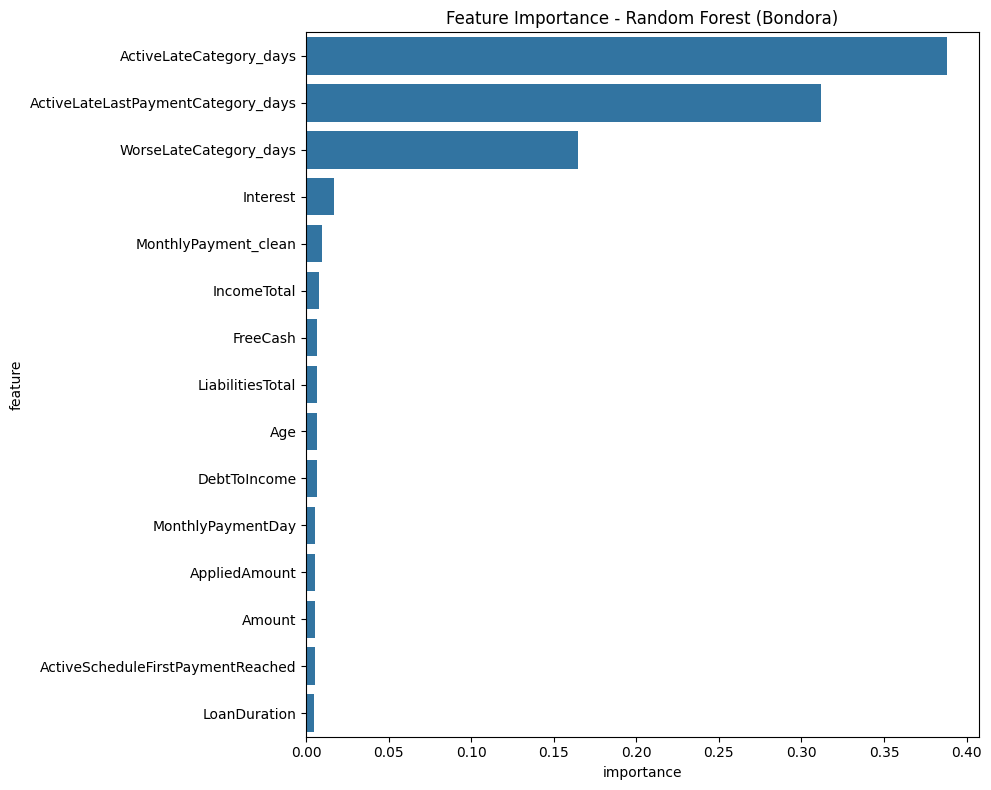

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Собираем важность признаков
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== ТОП-10 ВАЖНЫХ ПРИЗНАКОВ ===")
print(feature_importance.head(10))

# Визуализация
plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(15), x='importance', y='feature')
plt.title('Feature Importance - Random Forest (Bondora)')
plt.tight_layout()
plt.show()

In [ ]:
#проблема в том что мы уже знаем просрочку в данных и поэтому модель выдает крайне неоднозначные результаты

In [ ]:
#модель без признаков

In [60]:
# Убираем признаки-утечки (просрочки, которые не известны до дефолта)
leakage_cols = [
    'ActiveLateCategory_days',
    'ActiveLateLastPaymentCategory_days',
    'WorseLateCategory_days'
]

# Оставляем только честные признаки
X_clean = df.drop(leakage_cols + ['loan_default'], axis=1)
y_clean = df['loan_default']

# Разделяем
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

# Масштабируем
scaler_clean = StandardScaler()
X_train_clean_scaled = scaler_clean.fit_transform(X_train_clean)
X_test_clean_scaled = scaler_clean.transform(X_test_clean)

# Обучаем Random Forest
rf_clean = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clean.fit(X_train_clean_scaled, y_train_clean)

# Оцениваем
y_pred_clean = rf_clean.predict(X_test_clean_scaled)
y_pred_proba_clean = rf_clean.predict_proba(X_test_clean_scaled)[:, 1]

print("=== RANDOM FOREST (БЕЗ УТЕЧЕК) ===")
print(classification_report(y_test_clean, y_pred_clean))
print(f"AUC-ROC: {roc_auc_score(y_test_clean, y_pred_proba_clean):.3f}")


=== RANDOM FOREST (БЕЗ УТЕЧЕК) ===
              precision    recall  f1-score   support

           0       0.77      0.88      0.82     17752
           1       0.68      0.50      0.57      9154

    accuracy                           0.75     26906
   macro avg       0.72      0.69      0.70     26906
weighted avg       0.74      0.75      0.74     26906

AUC-ROC: 0.809
